C:\Users\junyew\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\junyew\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\junyew\AppData\Local\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\junyew\AppData\Local\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\junyew\AppData\Local\anaconda3\Lib\subprocess

Clustering Metrics:
Silhouette Score: 0.584
Davies-Bouldin Index: 0.554
Calinski-Harabasz Index: 891.616

Clustering Results:
Cluster 1:
  Size: 50 points
  Centroid: (-0.136, -0.072)
Cluster 2:
  Size: 49 points
  Centroid: (6.219, 5.976)
Cluster 3:
  Size: 51 points
  Centroid: (2.902, 3.176)
Cluster 4:
  Size: 50 points
  Centroid: (9.107, 9.131)


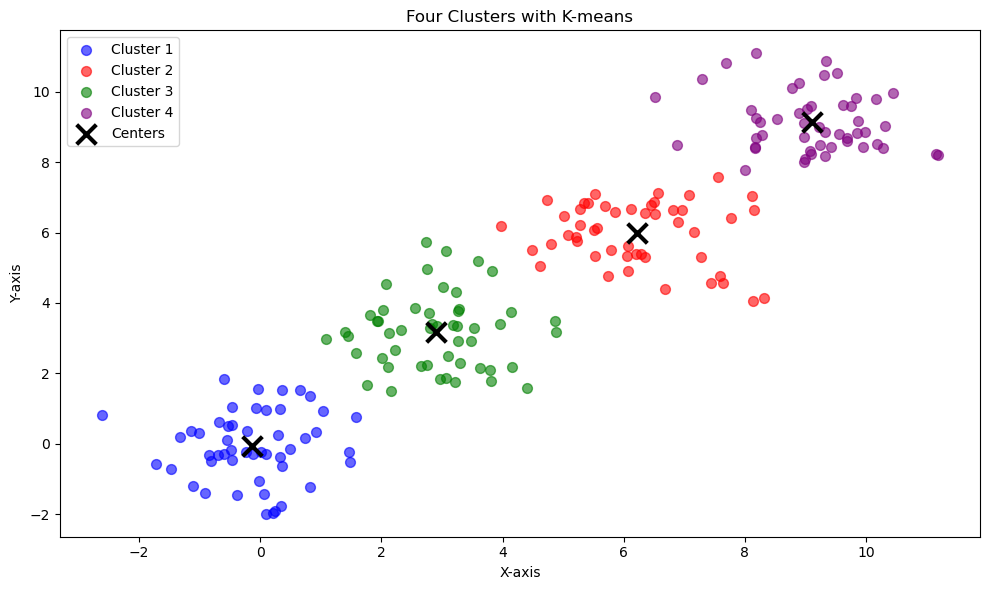

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Set random seed for reproducibility
np.random.seed(42)

# Generate data efficiently
n_points = 50
centers = [0, 3, 6, 9]
data = np.vstack([np.random.normal(loc, 1, (n_points, 2)) for loc in centers])

# Perform K-means clustering
kmeans = KMeans(n_clusters=4, 
                random_state=42,
                n_init=10,
                max_iter=100)
clusters = kmeans.fit_predict(data)

# Calculate clustering metrics
silhouette = silhouette_score(data, clusters)
davies_bouldin = davies_bouldin_score(data, clusters)
calinski_harabasz = calinski_harabasz_score(data, clusters)

# Print clustering metrics
print("Clustering Metrics:")
print(f"Silhouette Score: {silhouette:.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.3f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz:.3f}\n")

# Print clustering results
print("Clustering Results:")
for i in range(4):
    cluster_size = np.sum(clusters == i)
    centroid = kmeans.cluster_centers_[i]
    print(f"Cluster {i + 1}:")
    print(f"  Size: {cluster_size} points")
    print(f"  Centroid: ({centroid[0]:.3f}, {centroid[1]:.3f})")

# Define colors and labels
colors = ['blue', 'red', 'green', 'purple']
labels = [f'Cluster {i+1}' for i in range(4)]

# Create figure and plot
plt.figure(figsize=(10, 6))
for i in range(4):
    mask = clusters == i
    plt.scatter(data[mask, 0], data[mask, 1], 
                c=colors[i], 
                label=labels[i],
                s=50, 
                alpha=0.6)

# Plot centers
plt.scatter(kmeans.cluster_centers_[:, 0], 
            kmeans.cluster_centers_[:, 1],
            c='black', 
            marker='x', 
            s=200, 
            lw=3, 
            label='Centers')

# Customize plot
plt.title('Four Clusters with K-means')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.tight_layout()

# Display
plt.show()

Clustering Metrics:
Silhouette Score: 0.650
Davies-Bouldin Index: 2.382
Calinski-Harabasz Index: 1883.828

Clustering Results:
Cluster No.: 4
Noise points: 2


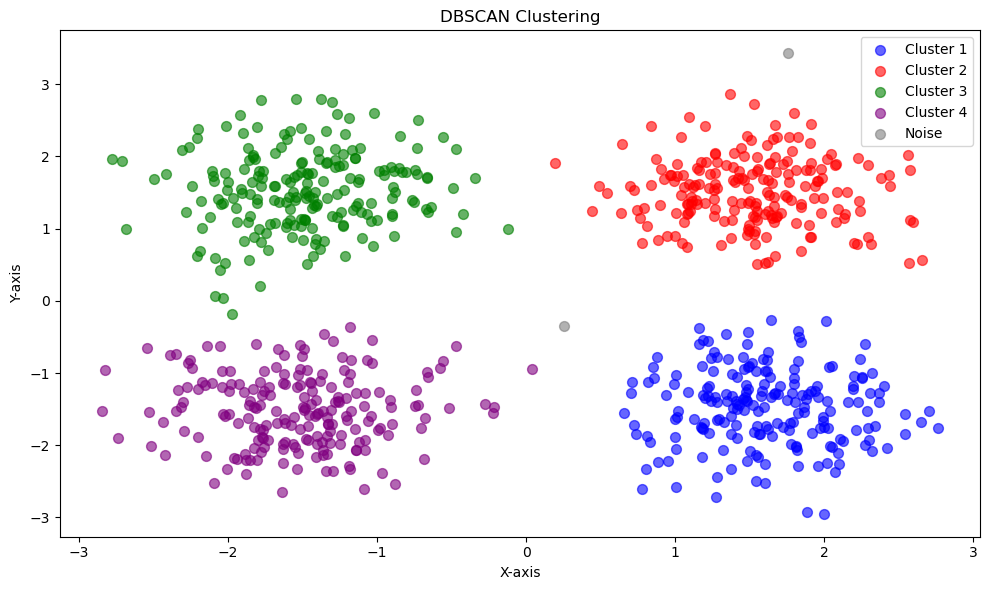

In [21]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics

# Generate sample data with different centers
cluster_centers = [[1.5, 1.5], [-1.5, -1.5], [1.5, -1.5], [-1.5, 1.5]]
X, labels_true = make_blobs(n_samples=800, centers=cluster_centers, cluster_std=0.5, random_state=42)

# Scale features using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN clustering
db = DBSCAN(eps=0.1, min_samples=10).fit(X_scaled)
labels = db.labels_

# Number of clusters (excluding noise points, labeled as -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

# Compute clustering metrics
clustering_stats = {
    "Silhouette Score": metrics.silhouette_score(X_scaled, labels) if n_clusters > 1 else -1,
    "Davies-Bouldin Index": metrics.davies_bouldin_score(X_scaled, labels) if n_clusters > 1 else -1,
    "Calinski-Harabasz Index": metrics.calinski_harabasz_score(X_scaled, labels) if n_clusters > 1 else -1
#    "Homogeneity": metrics.homogeneity_score(labels_true, labels),
#    "Completeness": metrics.completeness_score(labels_true, labels),
#    "V-measure": metrics.v_measure_score(labels_true, labels),
#    "Adjusted Rand Index": metrics.adjusted_rand_score(labels_true, labels),
#    "Adjusted Mutual Information": metrics.adjusted_mutual_info_score(labels_true, labels)
}

# Print clustering statistics
print("Clustering Metrics:")
for metric, value in clustering_stats.items():
    print(f"{metric}: {value:.3f}")

# Print clustering results
print(f"\nClustering Results:")
print(f"Cluster No.: {n_clusters}")
print(f"Noise points: {n_noise}")

# Plotting
plt.figure(figsize=(10, 6))
unique_labels = set(labels)
colors = ['blue', 'red', 'green', 'purple', 'gray']  # Add more colors if needed

for k, col in zip(unique_labels, colors[:len(unique_labels)]):
    if k == -1:
        # Noise points in gray
        col = 'gray'
        label = 'Noise'
    else:
        label = f'Cluster {k + 1}'
    
    mask = labels == k
    plt.scatter(X[mask, 0], X[mask, 1], c=col, label=label, s=50, alpha=0.6)

plt.title('DBSCAN Clustering')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.tight_layout()
plt.show()